In [ ]:
import sys
import os
import math

import numpy as np
import torch
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_pinball_loss
from gpytorch.mlls import VariationalELBO
from gpytorch_qr.likelihoods import MultitaskCenterGapQuantileGPLikelihood
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(".."))

try:
    import config_notebook
except ImportError:
    print("Output will not be deterministic SVG.")

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Run cross validation

In [ ]:
from scripts.cv import split_data, cross_validate

QUANTILES = torch.tensor([0.05, 0.25, 0.5, 0.75, 0.95])
CENTER_QUANTILE_INDEX = 2
NUM_LOWER_QUANTILES = 2
NUM_LATENTS = 3
NUM_LOWER_LATENTS = 1
K = 5

N_EPOCHS = int(os.getenv("HEAVYEDGE_N_EPOCHS", 10000))

X = pd.read_csv("../_temp/X.csv").values
y = pd.read_csv("../_temp/y.csv")["H"].values

x_train_cv, y_train_cv, x_test_cv, y_test_cv, x_scales, x_mins = split_data(
    X, y, K, device
)

## Center-gap LMC

In [ ]:
from scripts.model import MTGPQR_H

mtgpqr = MTGPQR_H(
    inducing_points=x_train_cv.clone().detach(),
    num_quantiles=len(QUANTILES),
    num_lower_quantiles=NUM_LOWER_QUANTILES,
    num_latents=NUM_LATENTS,
    num_lower_latents=NUM_LOWER_LATENTS,
    X_scale=x_scales,
    X_min=x_mins,
    batch_shape=torch.Size([K]),
).to(device)
likelihood = MultitaskCenterGapQuantileGPLikelihood(
    QUANTILES.unsqueeze(0),
    CENTER_QUANTILE_INDEX,
    torch.zeros((K, len(QUANTILES))),
    learn_scales=True,
).to(device)

mtgpqr_cv = cross_validate(
    x_train_cv,
    y_train_cv,
    x_test_cv,
    y_test_cv,
    QUANTILES,
    mtgpqr,
    likelihood,
    n_epochs=N_EPOCHS,
)

# Plot

In [ ]:
def sci_label(value: float, precision: int = 2) -> str:
    if value == 0:
        return f"{0:.{precision}f} × 10^0"
    exponent = math.floor(math.log10(abs(value)))
    mantissa = value / (10**exponent)
    return f"{mantissa:.{precision}f} × 10^{exponent}"

## CV loss by epoch

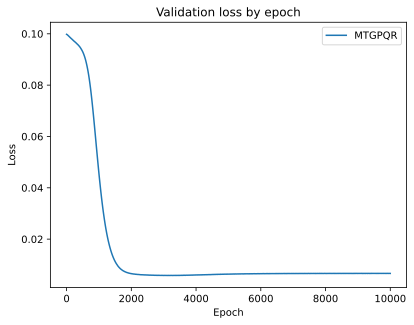

In [ ]:
plt.plot(mtgpqr_cv.mean(axis=1), label="MTGPQR")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Validation loss by epoch")
plt.legend()
plt.show()

## Minimum CV loss

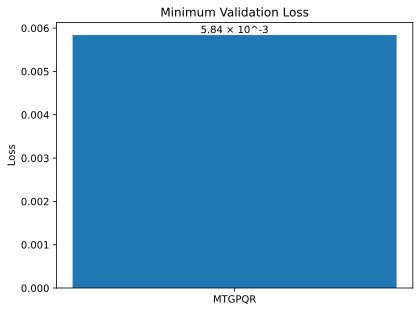

In [ ]:
names = ["MTGPQR"]
losses = [mtgpqr_cv.mean(axis=1).min()]

bars = plt.bar(names, losses)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        height,
        sci_label(height),
        ha="center",
        va="bottom",
    )

plt.ylabel("Loss")
plt.title("Minimum Validation Loss")
plt.show()

## Best epoch

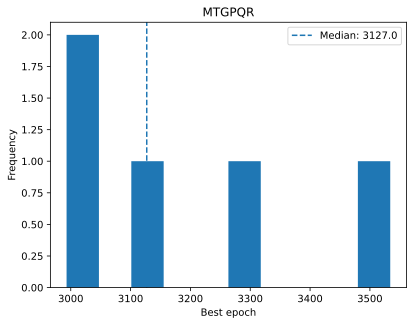

In [ ]:
mtgpqr_best_epochs = mtgpqr_cv.argmin(axis=0)
mtgpqr_epoch = np.median(mtgpqr_best_epochs)

plt.hist(mtgpqr_best_epochs)
plt.axvline(mtgpqr_epoch, ls="--", label=f"Median: {mtgpqr_epoch}")

plt.xlabel("Best epoch")
plt.ylabel("Frequency")
plt.title("MTGPQR")
plt.legend()
plt.show()